<a href="https://colab.research.google.com/github/parviza9999/InterviewN/blob/main/Vit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Learning Vision Transformers (ViT) with CIFAR-10

Vision Transformers (ViT) have revolutionized computer vision by applying the Transformer architecture, originally designed for natural language processing, directly to image data. Instead of processing images as a grid of pixels, ViT treats an image as a sequence of image patches, similar to how words are treated in a sentence.

Here's the plan to explore ViT:

1.  **Introduction to ViT**: Briefly explain the core concepts.
2.  **Dataset Selection**: We'll use the CIFAR-10 dataset, a common benchmark for image classification.
3.  **Data Loading and Preprocessing**: Load CIFAR-10 and prepare it for a ViT model, including patching and normalization.
4.  **ViT Model Implementation**: Implement or load a pre-trained ViT model.
5.  **Training and Evaluation**: Train the model on CIFAR-10 and evaluate its performance.

### Step 1: Install necessary libraries

In [ ]:
pip install torch torchvision transformers datasets accelerate

### Step 2: Load and Preprocess the CIFAR-10 Dataset

We'll use `torchvision.datasets` to easily download and load CIFAR-10. For preprocessing, we'll define transformations that resize images, convert them to tensors, and normalize pixel values. ViT models typically expect input images of a certain size (e.g., 224x224), so we'll resize the CIFAR-10 images (32x32) accordingly.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Define transformations for the CIFAR-10 dataset
# ViT models often expect 224x224 input images
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size for ViT
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])

# Load the CIFAR-10 training and test datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Class names: {train_dataset.classes}")

100%|██████████| 170M/170M [00:12<00:00, 14.0MB/s]


Number of training samples: 50000
Number of test samples: 10000
Image shape: torch.Size([3, 224, 224])
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Visualize some images from the dataset

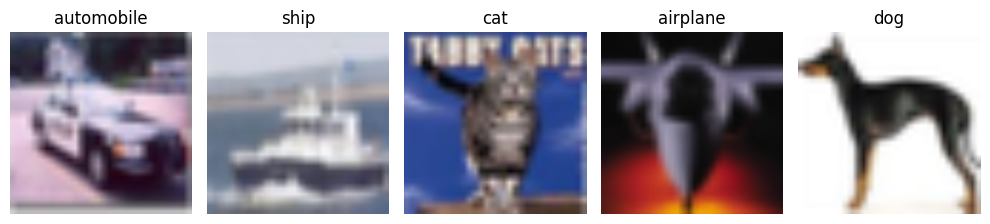

In [ ]:
# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize (if normalized with mean 0.5, std 0.5)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Unnormalize for display. Note: If using ImageNet stats, this might not perfectly reverse.
    # For accurate visualization, one might need to reverse ImageNet normalization steps.
    # For now, a simple unnormalization (if `transforms.Normalize` used common values like (0.5,0.5,0.5)) is applied.
    img = images[i]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean # reverse normalization
    npimg = img.numpy()
    plt.imshow(np.clip(np.transpose(npimg, (1, 2, 0)), 0, 1))
    plt.title(train_dataset.classes[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()